# Water Segmentation - Week 2: Pretrained Encoders (ResNet / EfficientNet) vs. the Scratch U-Net

**What this notebook does (builds on Week 1):**
1. Re-creates the exact Week 1 data pipeline (same split, same dataset-wide per-channel normalization, same engineered water indices - now with the index-clipping fix).
2. Researches pretrained backbones and **adapts the first convolution from 3 to 12 (or 16) input channels** (zero-init / weight-averaging strategies).
3. Loads a **pretrained encoder + U-Net / DeepLabV3+ decoder** from `segmentation-models-pytorch` and **fine-tunes** it.
4. Loads (or retrains) the **Week 1 scratch U-Nets** and compares everything with the same metrics (IoU, F1, Precision, Recall) on the same validation and test sets.

**Before you run on Kaggle (3 settings):**
- Accelerator: **GPU** (T4 x2 or P100).
- **Internet: ON** (needed to `pip install` the library and download the ImageNet weights).
- Attach your `water_data` dataset with **+ Add Input**. *(Optional)* also attach the Week 1 notebook's **output** as an input - the notebook then loads your saved Week 1 models instead of retraining them.


In [1]:
!pip install -q segmentation-models-pytorch tifffile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.0 MB/s eta 0:00:0000:01


In [2]:
import os, glob, json, time, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tifffile
from PIL import Image
import segmentation_models_pytorch as smp

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | smp {smp.__version__} | device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected -- Kaggle: Notebook Settings (right sidebar) > Accelerator > GPU T4 x2 (or P100).")

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PyTorch 2.11.0+cu128 | smp 0.5.0 | device: cuda
GPU: Tesla T4


## 1. Data: same files, same split as Week 1

The comparison is only fair if both weeks use **exactly the same train / validation / test images**. The split code below is identical to Week 1 (same stratification, same `SEED`), so the Week 1 models are evaluated on the same images they never trained on.

In [3]:
# Auto-detect the folder that contains both images/ and labels/ under /kaggle/input
candidates = [
    os.path.dirname(p) for p in glob.glob('/kaggle/input/**/images', recursive=True)
    if os.path.isdir(os.path.join(os.path.dirname(p), 'labels'))
]
assert candidates, ("No folder with both images/ and labels/ found under /kaggle/input -- "
                    "attach your water_data dataset via '+ Add Input' in the right sidebar.")
DATA_DIR   = candidates[0]
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
LABELS_DIR = os.path.join(DATA_DIR, 'labels')
print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

BAND_NAMES = ['Coastal aerosol', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2',
              'QA Band', 'Merit DEM', 'Copernicus DEM', 'ESA WorldCover', 'Water occurrence probability']

def to_chw(arr):
    """Standardize a loaded (H,W,12) or (12,H,W) array to channel-first (12,H,W) float32."""
    arr = np.asarray(arr)
    if arr.shape[0] == 12:
        pass
    elif arr.shape[-1] == 12:
        arr = np.transpose(arr, (2, 0, 1))
    else:
        raise ValueError(f"Can't find a 12-channel axis in shape {arr.shape}")
    return arr.astype(np.float32)

img_stems = {os.path.splitext(os.path.basename(f))[0] for f in glob.glob(os.path.join(IMAGES_DIR, '*.tif'))}
lbl_stems = {os.path.splitext(os.path.basename(f))[0] for f in glob.glob(os.path.join(LABELS_DIR, '*.png'))}
matched_stems = sorted(img_stems & lbl_stems)
print(f"Images: {len(img_stems)} | Labels: {len(lbl_stems)} | Matched pairs: {len(matched_stems)}")

sample = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, matched_stems[0] + '.tif')))
assert sample.shape == (12, 128, 128), f"Expected (12,128,128), got {sample.shape}"
print("Sample image shape (C,H,W):", sample.shape)

Images: /kaggle/input/datasets/amr33kassab/water-data/data/images
Labels: /kaggle/input/datasets/amr33kassab/water-data/data/labels
Images: 306 | Labels: 456 | Matched pairs: 306
Sample image shape (C,H,W): (12, 128, 128)


In [4]:
from sklearn.model_selection import train_test_split

water_fractions = np.array([
    (np.array(Image.open(os.path.join(LABELS_DIR, s + '.png'))) > 0).mean() for s in matched_stems
])
print(f"Overall water-pixel fraction: {water_fractions.mean()*100:.2f}% (mean over images)")

# IDENTICAL to Week 1: stratify by binned water fraction so each split has a similar mix of tiles.
water_bins = np.digitize(water_fractions, bins=[0.001, 0.1, 0.3, 0.6])
train_stems, temp_stems, train_bins, temp_bins = train_test_split(
    matched_stems, water_bins, test_size=0.20, random_state=SEED, stratify=water_bins)
val_stems, test_stems = train_test_split(
    temp_stems, test_size=0.50, random_state=SEED, stratify=temp_bins)
print(f"Train: {len(train_stems)}  Val: {len(val_stems)}  Test: {len(test_stems)}")

Overall water-pixel fraction: 25.98% (mean over images)
Train: 244  Val: 31  Test: 31


## 2. Preprocessing (Week 1 recap, with the fix)

1. **Dataset-wide, per-channel min/max** computed from the **training set only** (never per image).
2. **Water indices** (NDWI, MNDWI, NDVI + the ESA is-water flag). Each ratio is **clipped to [-1, 1]** before rescaling - this is the Week 1 bug fix (unclipped NDVI reached 4.0 and made the 16-channel model collapse to "all water").
3. **NEW for pretrained models - z-score standardization.** ImageNet backbones were trained on roughly zero-mean, unit-variance inputs, so for the pretrained models we additionally standardize every channel with dataset-wide (training-set) mean/std. The scratch models keep their original `[0,1]` inputs - **each model gets the preprocessing it was designed for** (the same lesson as the eye-disease project).

In [5]:
# --- 1. dataset-wide per-channel min/max (train set only) ---
STATS_PATH = os.path.join(OUTPUT_DIR, 'channel_minmax.json')

def compute_channel_minmax(stems):
    mins = np.full(12, np.inf); maxs = np.full(12, -np.inf)
    for stem in stems:
        img = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
        mins = np.minimum(mins, img.min(axis=(1, 2)))
        maxs = np.maximum(maxs, img.max(axis=(1, 2)))
    return {'min': mins.tolist(), 'max': maxs.tolist()}

if os.path.exists(STATS_PATH):
    minmax = json.load(open(STATS_PATH))
    print("Loaded existing min/max stats.")
else:
    t0 = time.time()
    minmax = compute_channel_minmax(train_stems)
    json.dump(minmax, open(STATS_PATH, 'w'), indent=2)
    print(f"Computed min/max over {len(train_stems)} training images in {time.time()-t0:.1f}s")

CH_MIN = np.array(minmax['min'], dtype=np.float32).reshape(-1, 1, 1)
CH_MAX = np.array(minmax['max'], dtype=np.float32).reshape(-1, 1, 1)

def normalize_channels(img):
    """Per-channel min-max scaling to [0,1] using FIXED train-set statistics."""
    return np.clip((img - CH_MIN) / np.maximum(CH_MAX - CH_MIN, 1e-6), 0, 1)

# --- 2. water indices (with the clipping fix) ---
EPS = 1e-6
EXTRA_FEATURE_NAMES = ['NDWI', 'MNDWI', 'NDVI', 'ESA is-water flag']

def compute_indices(raw_img):
    """raw_img: (12,H,W) RAW values. Returns (4,H,W) in [0,1]."""
    green, red, nir, swir1 = raw_img[2], raw_img[3], raw_img[4], raw_img[5]
    ndwi  = np.clip((green - nir)  / (green + nir  + EPS), -1, 1)
    mndwi = np.clip((green - swir1) / (green + swir1 + EPS), -1, 1)
    ndvi  = np.clip((nir - red)    / (nir + red    + EPS), -1, 1)
    esa_is_water = (np.round(raw_img[10]) == 80).astype(np.float32)
    return np.stack([(ndwi + 1) / 2, (mndwi + 1) / 2, (ndvi + 1) / 2, esa_is_water], axis=0).astype(np.float32)

def load_model_input(stem, use_engineered_features):
    """Returns (img (C,128,128) float32 in [0,1], mask (128,128) float32). C = 16 if engineered else 12."""
    raw = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
    mask = (np.array(Image.open(os.path.join(LABELS_DIR, stem + '.png'))) > 0).astype(np.float32)
    img = normalize_channels(raw)
    if use_engineered_features:
        img = np.concatenate([img, compute_indices(raw)], axis=0)
    return img.astype(np.float32), mask

def stretch(band, p_lo=2, p_hi=98):
    lo, hi = np.percentile(band, [p_lo, p_hi])
    return np.zeros_like(band) if hi <= lo else np.clip((band - lo) / (hi - lo), 0, 1)

# sanity: every channel must really live in [0,1]
_img, _mask = load_model_input(train_stems[0], True)
print("16-channel input shape:", _img.shape, "| min:", float(_img.min()), "| max:", float(_img.max()))
assert _img.min() >= 0 and _img.max() <= 1.0 + 1e-6, "A channel is out of [0,1] -- check the indices!"

Computed min/max over 244 training images in 3.0s
16-channel input shape: (16, 128, 128) | min: 0.0 | max: 1.0


In [6]:
# --- 3. z-score statistics of the FINAL 16-channel input (train set only), for the pretrained models ---
ZSTATS_PATH = os.path.join(OUTPUT_DIR, 'input_zscore_stats.json')

def compute_input_zstats(stems):
    s = np.zeros(16, dtype=np.float64); ss = np.zeros(16, dtype=np.float64); n = 0
    for stem in stems:
        img, _ = load_model_input(stem, True)
        s  += img.sum(axis=(1, 2), dtype=np.float64)
        ss += (img.astype(np.float64) ** 2).sum(axis=(1, 2))
        n  += img.shape[1] * img.shape[2]
    mean = s / n
    std = np.sqrt(np.maximum(ss / n - mean ** 2, 1e-12))
    return {'mean': mean.tolist(), 'std': np.maximum(std, 1e-6).tolist()}

if os.path.exists(ZSTATS_PATH):
    z = json.load(open(ZSTATS_PATH))
    print("Loaded existing z-score stats.")
else:
    t0 = time.time()
    z = compute_input_zstats(train_stems)
    json.dump(z, open(ZSTATS_PATH, 'w'), indent=2)
    print(f"Computed z-score stats in {time.time()-t0:.1f}s")

Z_MEAN = np.array(z['mean'], dtype=np.float32)
Z_STD  = np.array(z['std'],  dtype=np.float32)
ALL_NAMES = BAND_NAMES + EXTRA_FEATURE_NAMES
for i, n in enumerate(ALL_NAMES):
    print(f"  ch{i:2d} {n:<28s} mean={Z_MEAN[i]:.4f}  std={Z_STD[i]:.4f}")

Computed z-score stats in 1.2s
  ch 0 Coastal aerosol              mean=0.2246  std=0.0356
  ch 1 Blue                         mean=0.1491  std=0.0316
  ch 2 Green                        mean=0.1212  std=0.0356
  ch 3 Red                          mean=0.1262  std=0.0465
  ch 4 NIR                          mean=0.1518  std=0.0643
  ch 5 SWIR1                        mean=0.1459  std=0.0756
  ch 6 SWIR2                        mean=0.1066  std=0.0634
  ch 7 QA Band                      mean=0.2016  std=0.2562
  ch 8 Merit DEM                    mean=0.7120  std=0.1016
  ch 9 Copernicus DEM               mean=0.0727  std=0.1250
  ch10 ESA WorldCover               mean=0.2798  std=0.2249
  ch11 Water occurrence probability mean=0.0894  std=0.2528
  ch12 NDWI                         mean=0.3276  std=0.1851
  ch13 MNDWI                        mean=0.3600  std=0.2356
  ch14 NDVI                         mean=0.6514  std=0.1865
  ch15 ESA is-water flag            mean=0.1086  std=0.3111


## 3. Dataset & DataLoaders

`standardize=(mean, std)` switches on z-scoring (pretrained models); `None` keeps the Week 1 `[0,1]` inputs (scratch models). `use_engineered_features` selects 12 vs 16 channels.

In [7]:
class WaterSegDataset(Dataset):
    def __init__(self, stems, use_engineered_features=False, augment=False, standardize=None):
        self.stems = stems
        self.use_eng = use_engineered_features
        self.augment = augment
        self.standardize = standardize

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        img, mask = load_model_input(self.stems[idx], self.use_eng)
        if self.standardize is not None:
            mean, std = self.standardize
            c = img.shape[0]
            img = (img - mean[:c, None, None]) / std[:c, None, None]
        if self.augment:
            if random.random() < 0.5:
                img = np.flip(img, axis=2).copy(); mask = np.flip(mask, axis=1).copy()
            if random.random() < 0.5:
                img = np.flip(img, axis=1).copy(); mask = np.flip(mask, axis=0).copy()
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k, axes=(1, 2)).copy(); mask = np.rot90(mask, k, axes=(0, 1)).copy()
        return torch.from_numpy(img).float(), torch.from_numpy(mask).unsqueeze(0).float()

BATCH_SIZE = 16
_LOADER_CACHE = {}

def make_loaders(use_engineered_features, standardized):
    """Returns (train, val, test) loaders. Cached so repeated experiments reuse them."""
    key = (use_engineered_features, standardized)
    if key not in _LOADER_CACHE:
        std = (Z_MEAN, Z_STD) if standardized else None
        mk = lambda stems, aug, shuffle: DataLoader(
            WaterSegDataset(stems, use_engineered_features, augment=aug, standardize=std),
            batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2, pin_memory=True)
        _LOADER_CACHE[key] = (mk(train_stems, True, True), mk(val_stems, False, False), mk(test_stems, False, False))
    return _LOADER_CACHE[key]

xb, yb = next(iter(make_loaders(True, True)[0]))
print("Batch:", tuple(xb.shape), tuple(yb.shape), "| input mean/std (should be ~0/~1):",
      round(xb.mean().item(), 3), round(xb.std().item(), 3))

Batch: (16, 16, 128, 128) (16, 1, 128, 128) | input mean/std (should be ~0/~1): -0.021 0.867


## 4. Week 1 scratch U-Net (unchanged)

The class definitions must be **identical** to Week 1 so that saved Week 1 weights load correctly (layer names and shapes have to match).

In [8]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns per-channel importance weights."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid())

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)
        return x * w


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        if use_se:
            layers.append(SEBlock(out_ch))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch, use_se))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_se=False):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch, use_se)

    def forward(self, x, skip):
        x = self.upsample(x)
        diff_y = skip.size(2) - x.size(2); diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base_ch=32, use_se=False):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base_ch, use_se)
        self.down1 = Down(base_ch,     base_ch * 2,  use_se)
        self.down2 = Down(base_ch * 2, base_ch * 4,  use_se)
        self.down3 = Down(base_ch * 4, base_ch * 8,  use_se)
        self.down4 = Down(base_ch * 8, base_ch * 16, use_se)
        self.up1 = Up(base_ch * 16, base_ch * 8, base_ch * 8, use_se)
        self.up2 = Up(base_ch * 8,  base_ch * 4, base_ch * 4, use_se)
        self.up3 = Up(base_ch * 4,  base_ch * 2, base_ch * 2, use_se)
        self.up4 = Up(base_ch * 2,  base_ch,     base_ch,     use_se)
        self.outc = nn.Conv2d(base_ch, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)  # raw logits (B,1,H,W)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

## 5. Loss, metrics, training loop

Same Dice + BCE loss and the same pixel-level metrics as Week 1 (computed on the **water class**). The training loop is Week 1's, with two optional additions used only for fine-tuning: **a lower learning rate for the pretrained encoder** and **freezing the encoder for the first few epochs** (so the freshly initialized decoder does not wreck the pretrained features with large random gradients).

In [9]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits).reshape(logits.size(0), -1)
        t = targets.reshape(targets.size(0), -1)
        inter = (probs * t).sum(dim=1)
        dice = (2 * inter + self.smooth) / (probs.sum(dim=1) + t.sum(dim=1) + self.smooth)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * (1 - dice.mean())


@torch.no_grad()
def compute_confusion(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()
    return tp, fp, fn, tn


def metrics_from_confusion(tp, fp, fn, tn, eps=1e-7):
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    return {'iou': iou, 'f1': f1, 'precision': precision, 'recall': recall}


@torch.no_grad()
def evaluate_loader(model, loader):
    """Pixel-level IoU / F1 / Precision / Recall on the WATER class over a whole loader."""
    model = model.to(device).eval()
    tp = fp = fn = tn = 0
    for xb, yb in loader:
        logits = model(xb.to(device))
        a, b, c, d = compute_confusion(logits, yb.to(device))
        tp += a; fp += b; fn += c; tn += d
    return metrics_from_confusion(tp, fp, fn, tn)


@torch.no_grad()
def benchmark_inference(model, n_channels, batch_size=16, n_iter=20):
    """Average milliseconds per 128x128 image (forward pass only)."""
    model = model.to(device).eval()
    x = torch.randn(batch_size, n_channels, 128, 128, device=device)
    for _ in range(3):
        model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_iter):
        model(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.time() - t0) / (n_iter * batch_size) * 1000.0

In [10]:
def set_encoder_frozen(model, frozen):
    """Freeze/unfreeze the pretrained encoder. The adapted first conv always stays trainable
    (its new channels have to learn from the very first epoch)."""
    keep = getattr(model.encoder, '_first_conv_name', None)
    for name, p in model.encoder.named_parameters():
        is_first = keep is not None and name.startswith(keep + '.')
        p.requires_grad = (not frozen) or is_first


def train_model(model, train_loader, val_loader, model_name, epochs=30, lr=1e-3, patience=7,
                encoder_lr=None, freeze_encoder_epochs=0):
    model = model.to(device)
    if encoder_lr is not None and hasattr(model, 'encoder'):
        enc_params = list(model.encoder.parameters())
        enc_ids = {id(p) for p in enc_params}
        other = [p for p in model.parameters() if id(p) not in enc_ids]
        optimizer = torch.optim.Adam([{'params': enc_params, 'lr': encoder_lr}, {'params': other, 'lr': lr}])
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    criterion = DiceBCELoss()

    ckpt_path = os.path.join(OUTPUT_DIR, f'{model_name}_best.pt')
    best_val_f1, best_epoch, no_improve = -1.0, 0, 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
    if freeze_encoder_epochs > 0:
        set_encoder_frozen(model, True)
        print(f"[{model_name}] encoder frozen for the first {freeze_encoder_epochs} epochs (first conv + decoder train)")
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        if freeze_encoder_epochs > 0 and epoch == freeze_encoder_epochs + 1:
            set_encoder_frozen(model, False)
            print(f"[{model_name}] encoder UNFROZEN -> full fine-tuning from epoch {epoch}")

        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        val_loss, tp, fp, fn, tn = 0.0, 0, 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                a, b, c, d = compute_confusion(logits, yb)
                tp += a; fp += b; fn += c; tn += d
        val_loss /= len(val_loader.dataset)
        m = metrics_from_confusion(tp, fp, fn, tn)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['val_f1'].append(m['f1']); history['val_iou'].append(m['iou'])

        improved = m['f1'] > best_val_f1
        if improved:
            best_val_f1, best_epoch, no_improve = m['f1'], epoch, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
        print(f"[{model_name}] Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_F1={m['f1']:.4f} | val_IoU={m['iou']:.4f}" + ("  (best)" if improved else ""))
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no val_F1 improvement for {patience} epochs).")
            break

    history['best_epoch'] = best_epoch
    history['train_seconds'] = time.time() - t_start
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='train_loss'); axes[0].plot(history['val_loss'], label='val_loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_title(f'{title} - Loss'); axes[0].legend()
    axes[1].plot(history['val_f1'], label='val_F1'); axes[1].plot(history['val_iou'], label='val_IoU')
    axes[1].set_xlabel('Epoch'); axes[1].set_title(f'{title} - Val F1 / IoU'); axes[1].legend()
    plt.tight_layout(); plt.show()

## 6. Research: pretrained segmentation backbones for multispectral data

**Transfer learning in one paragraph.** A network pretrained on ImageNet has already learned generic visual building blocks - edges, corners, textures, blobs - in its early layers. Those transfer well to almost any image domain, including satellite tiles. Starting from them usually means faster convergence and better results than random initialization, especially with a modest dataset.

**Candidate encoders** (all available in `segmentation-models-pytorch`):

| Encoder | Core idea | Size (encoder only, approx.) | Notes for this task |
| --- | --- | --- | --- |
| ResNet18 / 34 / 50 | Residual (skip) connections let very deep nets train; BatchNorm after each conv | 11M / 21M / 23M | Robust, easy to fine-tune, the standard default. We use **ResNet34**. |
| EfficientNet-B0..B7 | Compound scaling of depth/width/resolution; depthwise convs + squeeze-and-excitation | 4M (B0) and up | Very parameter-efficient, but more sensitive to learning rate and slower per FLOP on GPU. Loaded as `tu-efficientnet_b0` (timm). |
| MobileNet / ResNeXt / SE-ResNet / ConvNeXt | Lighter or stronger variants | varies | MobileNet is the pick if real-time on weak hardware matters. |

*(Remote-sensing-specific pretraining such as SSL4EO-S12 or Prithvi exists and would match multispectral data better, but it is outside this assignment's scope.)*

**Decoders.** The *U-Net decoder* upsamples step by step and concatenates the encoder feature map at each resolution (skip connections) - great for sharp boundaries. *DeepLabV3+* adds **ASPP** (atrous/dilated convolutions at several rates) to capture multi-scale context, then fuses it with a low-level feature map. We use U-Net as the main decoder and keep DeepLabV3+ as an optional extra experiment.

**The core problem: ImageNet backbones expect 3 channels, our data has 12 (16 with indices).**
The first layer (a 7x7 conv for ResNet) has weights of shape `(64, 3, 7, 7)`. We must replace it with `(64, C, 7, 7)`. Options:

| Strategy | What the new weights are | Behaviour at the start of fine-tuning |
| --- | --- | --- |
| **zero_init** (our default) | Pretrained R/G/B filters are copied onto the **Red/Green/Blue band positions**; all other channels get **zeros** | The network behaves *exactly* like the pretrained RGB network; the extra bands start contributing as their weights learn away from zero (gradients are non-zero even though weights are zero). |
| **mean** (weight averaging) | Every channel gets the *average* of the 3 pretrained filters, scaled by `3/C` so the output magnitude stays similar | All bands start with equal, generic influence. Simple, but loses the colour-specific meaning of R/G/B. |
| random | Fresh Kaiming-random weights | Throws away the pretrained first layer (ablation baseline). |

*(smp's own built-in behaviour for `in_channels > 3` is to cycle the RGB filters and rescale - a variant of the averaging idea. We implement the adaptation ourselves so the strategy is explicit and testable.)*

## 7. Adapting the first convolution to 12 (or 16) channels

In [11]:
RGB_BAND_IDX = (3, 2, 1)   # positions of Red, Green, Blue in OUR channel stack (ImageNet filters are ordered R, G, B)

def adapt_first_conv(model, in_channels, init='zero_init', rgb_band_idx=RGB_BAND_IDX, verify=True):
    """Replace the encoder's first 3-channel conv with an `in_channels` conv, initialised from the pretrained weights."""
    enc = model.encoder
    found = [(n, m) for n, m in enc.named_modules() if isinstance(m, nn.Conv2d) and m.in_channels == 3]
    assert found, "No 3-channel convolution found in the encoder"
    name, old = found[0]
    W = old.weight.data.clone()                       # (out, 3, kh, kw), filters ordered R, G, B
    out_c = W.shape[0]

    if init == 'zero_init':
        new_w = torch.zeros(out_c, in_channels, *W.shape[2:])
        for src, dst in enumerate(rgb_band_idx):      # src: 0=R, 1=G, 2=B filter  ->  dst: band position
            new_w[:, dst] = W[:, src]
    elif init == 'mean':
        new_w = W.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1) * (3.0 / in_channels)
    elif init == 'random':
        new_w = torch.empty(out_c, in_channels, *W.shape[2:])
        nn.init.kaiming_normal_(new_w, mode='fan_out', nonlinearity='relu')
    else:
        raise ValueError(f"Unknown init '{init}' (use zero_init | mean | random)")

    new_conv = nn.Conv2d(in_channels, out_c, kernel_size=old.kernel_size, stride=old.stride,
                         padding=old.padding, dilation=old.dilation, groups=old.groups, bias=old.bias is not None)
    with torch.no_grad():
        new_conv.weight.copy_(new_w)
        if old.bias is not None:
            new_conv.bias.copy_(old.bias)

    if verify and init == 'zero_init':
        # With zero-init the new layer must equal the OLD layer applied to just the R,G,B bands.
        x = torch.randn(2, in_channels, 32, 32)
        with torch.no_grad():
            assert torch.allclose(new_conv(x), old(x[:, list(rgb_band_idx)]), atol=1e-5), "zero_init check failed"

    parent = enc
    parts = name.split('.')
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new_conv)
    enc._first_conv_name = name
    if hasattr(enc, '_in_channels'):
        enc._in_channels = in_channels
    return model


def build_pretrained_model(arch, encoder_name, in_channels, init='zero_init'):
    ctor = {'Unet': smp.Unet, 'DeepLabV3Plus': smp.DeepLabV3Plus}[arch]
    try:
        model = ctor(encoder_name=encoder_name, encoder_weights='imagenet', in_channels=3, classes=1)
    except Exception as e:
        raise RuntimeError(
            f"Could not create {arch} / {encoder_name} with ImageNet weights ({type(e).__name__}: {e}). "
            f"On Kaggle: turn Internet ON in the notebook settings (right sidebar) and re-run this cell.") from e
    return adapt_first_conv(model, in_channels, init)

In [12]:
# Demo: build the model, inspect the new first layer, and check shapes
demo = build_pretrained_model('Unet', 'resnet34', in_channels=12, init='zero_init')
conv = demo.encoder.conv1
print("New first conv:", conv)
print("Weight shape:", tuple(conv.weight.shape), " (was (64, 3, 7, 7))")

w = conv.weight.detach().abs().mean(dim=(0, 2, 3))
print("\nMean |weight| per input channel right after zero_init:")
for i, n in enumerate(BAND_NAMES):
    print(f"  ch{i:2d} {n:<28s} {w[i].item():.4f}" + ("   <- pretrained RGB filter" if i in RGB_BAND_IDX else "   (zero)"))

with torch.no_grad():
    out = demo.eval()(torch.randn(2, 12, 128, 128))
print("\nForward pass:", (2, 12, 128, 128), "->", tuple(out.shape))
total, trainable = count_params(demo)
print(f"Parameters: {total/1e6:.2f}M total, {trainable/1e6:.2f}M trainable")
del demo

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

New first conv: Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Weight shape: (64, 12, 7, 7)  (was (64, 3, 7, 7))

Mean |weight| per input channel right after zero_init:
  ch 0 Coastal aerosol              0.0000   (zero)
  ch 1 Blue                         0.0578   <- pretrained RGB filter
  ch 2 Green                        0.0816   <- pretrained RGB filter
  ch 3 Red                          0.0736   <- pretrained RGB filter
  ch 4 NIR                          0.0000   (zero)
  ch 5 SWIR1                        0.0000   (zero)
  ch 6 SWIR2                        0.0000   (zero)
  ch 7 QA Band                      0.0000   (zero)
  ch 8 Merit DEM                    0.0000   (zero)
  ch 9 Copernicus DEM               0.0000   (zero)
  ch10 ESA WorldCover               0.0000   (zero)
  ch11 Water occurrence probability 0.0000   (zero)

Forward pass: (2, 12, 128, 128) -> (2, 1, 128, 128)
Parameters: 24.46M total, 24.46M trainable


## 8. Week 1 scratch models: load saved weights, or retrain

The comparison needs the Week 1 scratch U-Nets. The cell looks for saved Week 1 weights (`unet_baseline_final.pt` / `unet_baseline_best.pt`, and the same for `unet_enhanced`) under `/kaggle/input` and `/kaggle/working`. **If none are found it retrains them** with the identical Week 1 recipe (same split, same loss, 30 epochs, early stopping) - slower but fully reproducible. A loaded model whose validation F1 is suspiciously low (< 0.55, e.g. the collapsed pre-fix 16-channel model) is discarded and retrained.

In [13]:
results, trained, histories = {}, {}, {}

def record(name, model, channels, standardized, hist=None):
    """Evaluate on val AND test, time inference, and store everything for the comparison."""
    _, val_loader, test_loader = make_loaders(channels == 16, standardized)
    total, _ = count_params(model)
    results[name] = dict(
        channels=channels, params_m=total / 1e6,
        ms_per_img=benchmark_inference(model, channels),
        val=evaluate_loader(model, val_loader), test=evaluate_loader(model, test_loader))
    trained[name] = dict(model=model.cpu(), channels=channels, standardized=standardized)
    if hist is not None:
        histories[name] = hist
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    r = results[name]
    print(f"==> {name}: VAL IoU={r['val']['iou']:.4f} F1={r['val']['f1']:.4f} | "
          f"TEST IoU={r['test']['iou']:.4f} F1={r['test']['f1']:.4f}")


def find_checkpoint(filenames):
    for root in ['/kaggle/input', OUTPUT_DIR]:
        for fn in filenames:
            hits = glob.glob(os.path.join(root, '**', fn), recursive=True)
            if hits:
                return hits[0]
    return None


SCRATCH_SPECS = [
    dict(name='Week 1 scratch U-Net (12ch)',    key='unet_baseline', channels=12, use_se=False),
    dict(name='Week 1 scratch U-Net (16ch+SE)', key='unet_enhanced', channels=16, use_se=True),
]
TRAIN_SCRATCH_IF_MISSING = True

for spec in SCRATCH_SPECS:
    name, key, ch = spec['name'], spec['key'], spec['channels']
    train_l, val_l, _ = make_loaders(ch == 16, False)      # scratch models keep their original [0,1] inputs
    make = lambda: UNet(in_channels=ch, use_se=spec['use_se'], base_ch=32)
    model, hist, usable = make(), None, False

    ckpt = find_checkpoint([f'{key}_final.pt', f'{key}_best.pt'])
    if ckpt:
        model.load_state_dict(torch.load(ckpt, map_location='cpu'))
        f1 = evaluate_loader(model, val_l)['f1']
        usable = f1 >= 0.55
        print(f"[{name}] found {ckpt} -> val F1 {f1:.4f} -> " + ("using it." if usable else "looks collapsed/invalid, ignoring."))

    if not usable:
        if not TRAIN_SCRATCH_IF_MISSING:
            print(f"[{name}] no usable checkpoint and TRAIN_SCRATCH_IF_MISSING=False -> skipped."); continue
        print(f"[{name}] training from scratch (Week 1 recipe)...")
        model, hist = train_model(make(), train_l, val_l, key, epochs=30, lr=1e-3, patience=7)

    record(name, model, ch, False, hist)

[Week 1 scratch U-Net (12ch)] training from scratch (Week 1 recipe)...
[unet_baseline] Epoch   1/30 | train_loss=0.5713 | val_loss=0.6649 | val_F1=0.0033 | val_IoU=0.0016  (best)
[unet_baseline] Epoch   2/30 | train_loss=0.5122 | val_loss=0.5793 | val_F1=0.4467 | val_IoU=0.2876  (best)
[unet_baseline] Epoch   3/30 | train_loss=0.4902 | val_loss=0.4989 | val_F1=0.7765 | val_IoU=0.6347  (best)
[unet_baseline] Epoch   4/30 | train_loss=0.4682 | val_loss=0.4571 | val_F1=0.7625 | val_IoU=0.6162
[unet_baseline] Epoch   5/30 | train_loss=0.4546 | val_loss=0.4685 | val_F1=0.7740 | val_IoU=0.6313
[unet_baseline] Epoch   6/30 | train_loss=0.4403 | val_loss=0.4071 | val_F1=0.7899 | val_IoU=0.6528  (best)
[unet_baseline] Epoch   7/30 | train_loss=0.4393 | val_loss=0.4279 | val_F1=0.7660 | val_IoU=0.6207
[unet_baseline] Epoch   8/30 | train_loss=0.4195 | val_loss=0.4156 | val_F1=0.7831 | val_IoU=0.6435
[unet_baseline] Epoch   9/30 | train_loss=0.4144 | val_loss=0.4270 | val_F1=0.7605 | val_IoU=0.61

## 9. Fine-tune the pretrained models

**Recipe** (the same loss, split, epoch budget and early stopping as Week 1, so only the model changes):
- Inputs: z-score standardized (what ImageNet backbones expect).
- **Differential learning rates:** decoder `1e-3`, pretrained encoder `1e-4` - the encoder already knows useful features and should only be nudged.
- **Warm-up:** encoder frozen for the first 2 epochs (only the new first-conv weights and the random decoder train), then everything is fine-tuned.
- Best epoch chosen by validation F1; the best checkpoint is reloaded before evaluation.


Pretrained ResNet34 U-Net (12ch)
Parameters: 24.46M total
[pretrained_resnet34_u_net_12ch] encoder frozen for the first 2 epochs (first conv + decoder train)
[pretrained_resnet34_u_net_12ch] Epoch   1/30 | train_loss=0.6175 | val_loss=1.7828 | val_F1=0.5722 | val_IoU=0.4008  (best)
[pretrained_resnet34_u_net_12ch] Epoch   2/30 | train_loss=0.4957 | val_loss=0.5093 | val_F1=0.6997 | val_IoU=0.5381  (best)
[pretrained_resnet34_u_net_12ch] encoder UNFROZEN -> full fine-tuning from epoch 3
[pretrained_resnet34_u_net_12ch] Epoch   3/30 | train_loss=0.4511 | val_loss=0.4405 | val_F1=0.7454 | val_IoU=0.5942  (best)
[pretrained_resnet34_u_net_12ch] Epoch   4/30 | train_loss=0.4097 | val_loss=0.4101 | val_F1=0.7579 | val_IoU=0.6102  (best)
[pretrained_resnet34_u_net_12ch] Epoch   5/30 | train_loss=0.4036 | val_loss=0.4073 | val_F1=0.7927 | val_IoU=0.6566  (best)
[pretrained_resnet34_u_net_12ch] Epoch   6/30 | train_loss=0.3832 | val_loss=0.3968 | val_F1=0.8102 | val_IoU=0.6810  (best)
[pretrai

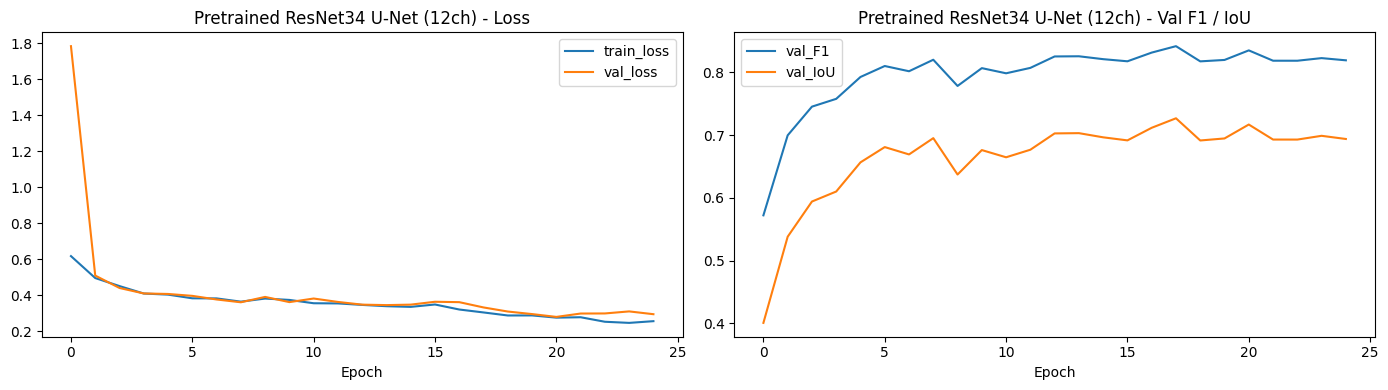

==> Pretrained ResNet34 U-Net (12ch): VAL IoU=0.7269 F1=0.8418 | TEST IoU=0.7185 F1=0.8362

Pretrained ResNet34 U-Net (16ch)
Parameters: 24.48M total
[pretrained_resnet34_u_net_16ch] encoder frozen for the first 2 epochs (first conv + decoder train)
[pretrained_resnet34_u_net_16ch] Epoch   1/30 | train_loss=0.5888 | val_loss=0.6542 | val_F1=0.6329 | val_IoU=0.4630  (best)
[pretrained_resnet34_u_net_16ch] Epoch   2/30 | train_loss=0.4555 | val_loss=0.4450 | val_F1=0.7529 | val_IoU=0.6038  (best)
[pretrained_resnet34_u_net_16ch] encoder UNFROZEN -> full fine-tuning from epoch 3
[pretrained_resnet34_u_net_16ch] Epoch   3/30 | train_loss=0.4165 | val_loss=0.4269 | val_F1=0.7551 | val_IoU=0.6066  (best)
[pretrained_resnet34_u_net_16ch] Epoch   4/30 | train_loss=0.3865 | val_loss=0.4112 | val_F1=0.7895 | val_IoU=0.6522  (best)
[pretrained_resnet34_u_net_16ch] Epoch   5/30 | train_loss=0.3929 | val_loss=0.4126 | val_F1=0.7794 | val_IoU=0.6385
[pretrained_resnet34_u_net_16ch] Epoch   6/30 | tr

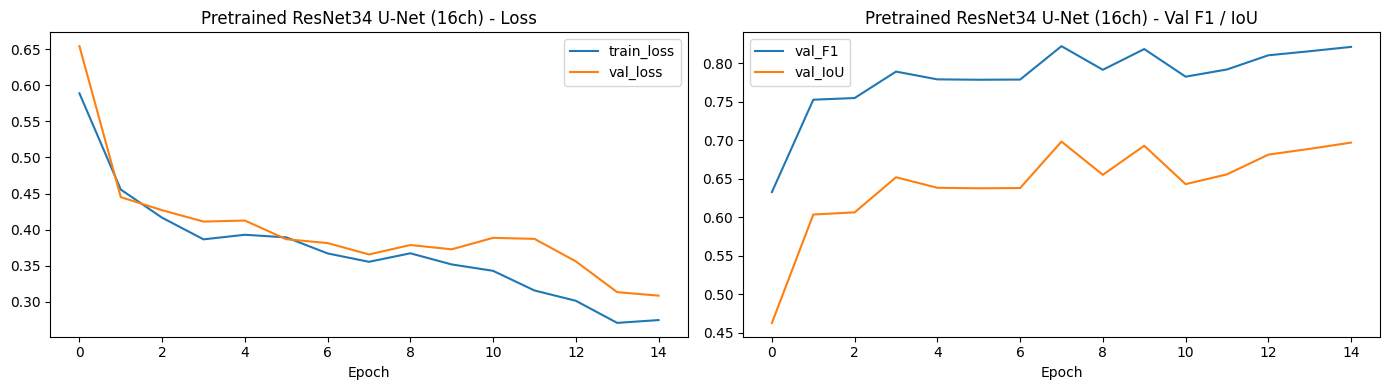

==> Pretrained ResNet34 U-Net (16ch): VAL IoU=0.6985 F1=0.8225 | TEST IoU=0.6779 F1=0.8080


In [14]:
import re, traceback

PRETRAINED_CFG = dict(epochs=30, lr=1e-3, encoder_lr=1e-4, freeze_encoder_epochs=2, patience=7)

EXPERIMENTS = [
    dict(name='Pretrained ResNet34 U-Net (12ch)', arch='Unet', encoder='resnet34', channels=12, init='zero_init'),
    dict(name='Pretrained ResNet34 U-Net (16ch)', arch='Unet', encoder='resnet34', channels=16, init='zero_init'),
]

# Optional extras (first-conv strategy ablation, DeepLabV3+, EfficientNet). Set True if you have GPU time left.
RUN_EXTRA_EXPERIMENTS = False
EXTRA_EXPERIMENTS = [
    dict(name='Pretrained ResNet34 U-Net (12ch, mean-init)',   arch='Unet', encoder='resnet34', channels=12, init='mean'),
    dict(name='Pretrained ResNet34 U-Net (12ch, random-init)', arch='Unet', encoder='resnet34', channels=12, init='random'),
    dict(name='Pretrained ResNet34 DeepLabV3+ (16ch)',         arch='DeepLabV3Plus', encoder='resnet34', channels=16, init='zero_init'),
    dict(name='Pretrained EfficientNet-B0 U-Net (16ch)',       arch='Unet', encoder='tu-efficientnet_b0', channels=16, init='zero_init'),
]

for exp in EXPERIMENTS + (EXTRA_EXPERIMENTS if RUN_EXTRA_EXPERIMENTS else []):
    print("\n" + "=" * 80 + f"\n{exp['name']}\n" + "=" * 80)
    try:
        model = build_pretrained_model(exp['arch'], exp['encoder'], exp['channels'], exp['init'])
        tot, trn = count_params(model)
        print(f"Parameters: {tot/1e6:.2f}M total")
        train_l, val_l, _ = make_loaders(exp['channels'] == 16, True)
        key = re.sub(r'[^A-Za-z0-9]+', '_', exp['name']).strip('_').lower()
        model, hist = train_model(model, train_l, val_l, key, **PRETRAINED_CFG)
        plot_history(hist, exp['name'])
        record(exp['name'], model, exp['channels'], True, hist)
    except Exception:
        print(f"!! Experiment '{exp['name']}' failed:")
        traceback.print_exc()

## 10. Comparison: pretrained vs. scratch (same split, same metrics)

All numbers are pixel-level metrics on the **water class**. The best epoch of every model was chosen on the validation set, so validation scores are slightly optimistic for *all* models; the **test** columns are the cleaner comparison.

In [15]:
from IPython.display import display

def results_table():
    rows = []
    for name, r in results.items():
        h = histories.get(name, {})
        rows.append({
            'Model': name, 'Ch': r['channels'], 'Params (M)': r['params_m'], 'ms/img': r['ms_per_img'],
            'Train (min)': h.get('train_seconds', float('nan')) / 60.0,
            'Val IoU': r['val']['iou'], 'Val F1': r['val']['f1'], 'Val Prec': r['val']['precision'], 'Val Rec': r['val']['recall'],
            'Test IoU': r['test']['iou'], 'Test F1': r['test']['f1'], 'Test Prec': r['test']['precision'], 'Test Rec': r['test']['recall']})
    return pd.DataFrame(rows)

df = results_table()
display(df.style.format({c: '{:.4f}' for c in df.columns if c.startswith(('Val', 'Test'))} |
                        {'Params (M)': '{:.1f}', 'ms/img': '{:.2f}', 'Train (min)': '{:.1f}'}))
df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'), index=False)

def to_markdown(d):
    cols = list(d.columns)
    fmt = lambda c, v: (f"{v:.4f}" if c.startswith(('Val', 'Test')) else f"{v:.1f}" if c in ('Params (M)', 'Train (min)') else
                        f"{v:.2f}" if c == 'ms/img' else str(v))
    lines = ['| ' + ' | '.join(cols) + ' |', '| ' + ' | '.join(['---'] * len(cols)) + ' |']
    lines += ['| ' + ' | '.join(fmt(c, row[c]) for c in cols) + ' |' for _, row in d.iterrows()]
    return '\n'.join(lines)

print("\nMarkdown version (paste into your README):\n")
print(to_markdown(df))

,Model,Ch,Params (M),ms/img,Train (min),Val IoU,Val F1,Val Prec,Val Rec,Test IoU,Test F1,Test Prec,Test Rec
0,Week 1 scratch U-Net (12ch),12,7.8,1.40,0.4,0.6528,0.7899,0.8496,0.7381,0.6640,0.7981,0.7780,0.8193
1,Week 1 scratch U-Net (16ch+SE),16,7.9,1.57,0.5,0.6872,0.8146,0.8716,0.7645,0.6280,0.7715,0.7155,0.8370
2,Pretrained ResNet34 U-Net (12ch),12,24.5,1.18,0.7,0.7269,0.8418,0.8497,0.8341,0.7185,0.8362,0.8072,0.8673
3,Pretrained ResNet34 U-Net (16ch),16,24.5,1.32,0.4,0.6985,0.8225,0.8513,0.7956,0.6779,0.8080,0.7944,0.8221



Markdown version (paste into your README):

| Model | Ch | Params (M) | ms/img | Train (min) | Val IoU | Val F1 | Val Prec | Val Rec | Test IoU | Test F1 | Test Prec | Test Rec |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Week 1 scratch U-Net (12ch) | 12 | 7.8 | 1.40 | 0.4 | 0.6528 | 0.7899 | 0.8496 | 0.7381 | 0.6640 | 0.7981 | 0.7780 | 0.8193 |
| Week 1 scratch U-Net (16ch+SE) | 16 | 7.9 | 1.57 | 0.5 | 0.6872 | 0.8146 | 0.8716 | 0.7645 | 0.6280 | 0.7715 | 0.7155 | 0.8370 |
| Pretrained ResNet34 U-Net (12ch) | 12 | 24.5 | 1.18 | 0.7 | 0.7269 | 0.8418 | 0.8497 | 0.8341 | 0.7185 | 0.8362 | 0.8072 | 0.8673 |
| Pretrained ResNet34 U-Net (16ch) | 16 | 24.5 | 1.32 | 0.4 | 0.6985 | 0.8225 | 0.8513 | 0.7956 | 0.6779 | 0.8080 | 0.7944 | 0.8221 |


In [16]:
# --- Completion-requirement check: does the best pretrained model beat the best Week 1 scratch model? ---
MIN_GAIN = 0.01   # we call an IoU gain "measurable" if it is at least 1 IoU point (0.01)
scratch = [n for n in results if n.startswith('Week 1')]
pre     = [n for n in results if n.startswith('Pretrained')]

if scratch and pre:
    best_s = max(scratch, key=lambda n: results[n]['val']['iou'])
    best_p = max(pre,     key=lambda n: results[n]['val']['iou'])
    for split in ('val', 'test'):
        s, p = results[best_s][split]['iou'], results[best_p][split]['iou']
        verdict = 'MET' if p - s >= MIN_GAIN else 'NOT MET'
        print(f"{split.upper():>4} IoU | best scratch: {s:.4f} ({best_s}) | best pretrained: {p:.4f} ({best_p}) | "
              f"gain {p - s:+.4f} -> requirement (>= +{MIN_GAIN}) {verdict}")
else:
    print("Need at least one scratch and one pretrained result to compare.")

 VAL IoU | best scratch: 0.6872 (Week 1 scratch U-Net (16ch+SE)) | best pretrained: 0.7269 (Pretrained ResNet34 U-Net (12ch)) | gain +0.0397 -> requirement (>= +0.01) MET
TEST IoU | best scratch: 0.6280 (Week 1 scratch U-Net (16ch+SE)) | best pretrained: 0.7185 (Pretrained ResNet34 U-Net (12ch)) | gain +0.0905 -> requirement (>= +0.01) MET


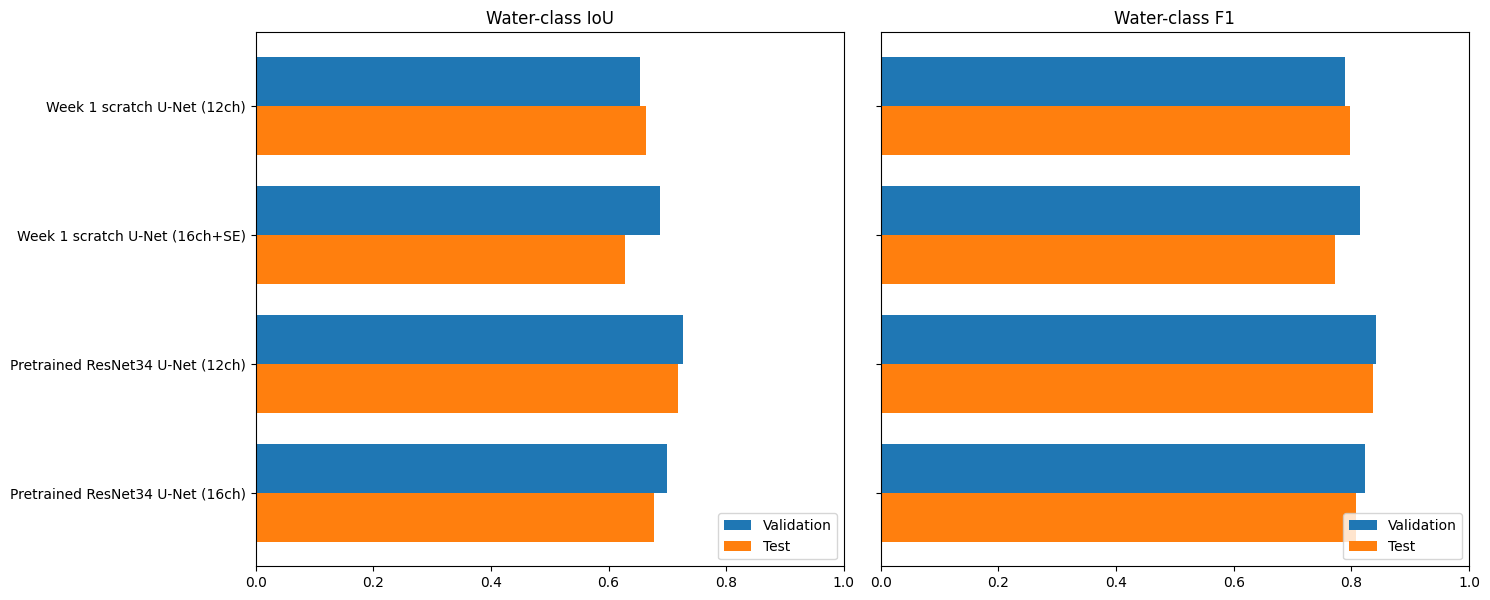

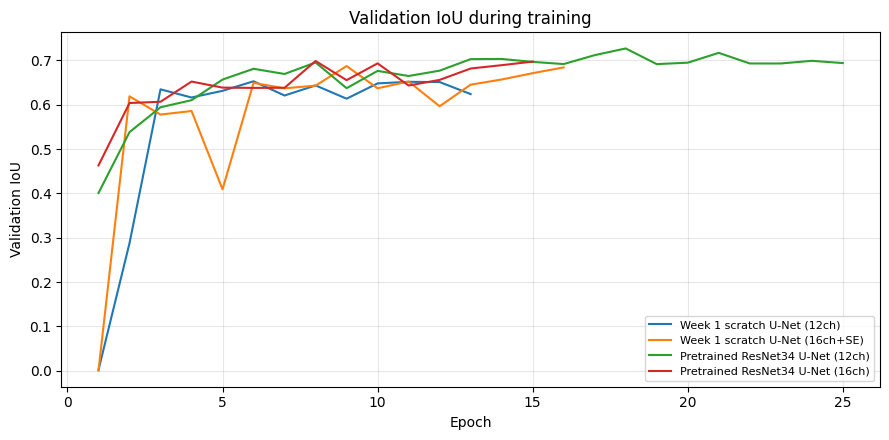

In [17]:
# Bar chart: IoU and F1, validation vs. test
names = list(results.keys())
fig, axes = plt.subplots(1, 2, figsize=(15, 0.9 * len(names) + 2.5))
y = np.arange(len(names)); h = 0.38
for ax, metric, label in zip(axes, ['iou', 'f1'], ['IoU', 'F1']):
    ax.barh(y - h/2, [results[n]['val'][metric]  for n in names], h, label='Validation')
    ax.barh(y + h/2, [results[n]['test'][metric] for n in names], h, label='Test')
    ax.set_yticks(y); ax.set_yticklabels(names if metric == 'iou' else [''] * len(names))
    ax.set_xlim(0, 1); ax.set_title(f'Water-class {label}'); ax.invert_yaxis(); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_bars.png'), dpi=100, bbox_inches='tight'); plt.show()

# Validation IoU curves for every model that was trained in this session
if histories:
    plt.figure(figsize=(9, 4.5))
    for n, hst in histories.items():
        plt.plot(range(1, len(hst['val_iou']) + 1), hst['val_iou'], label=n)
    plt.xlabel('Epoch'); plt.ylabel('Validation IoU'); plt.title('Validation IoU during training'); plt.legend(fontsize=8); plt.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'val_iou_curves.png'), dpi=100, bbox_inches='tight'); plt.show()

## 11. Qualitative comparison

Green = correctly found water, **red = false alarm** (predicted water, is not), **blue = missed water**.

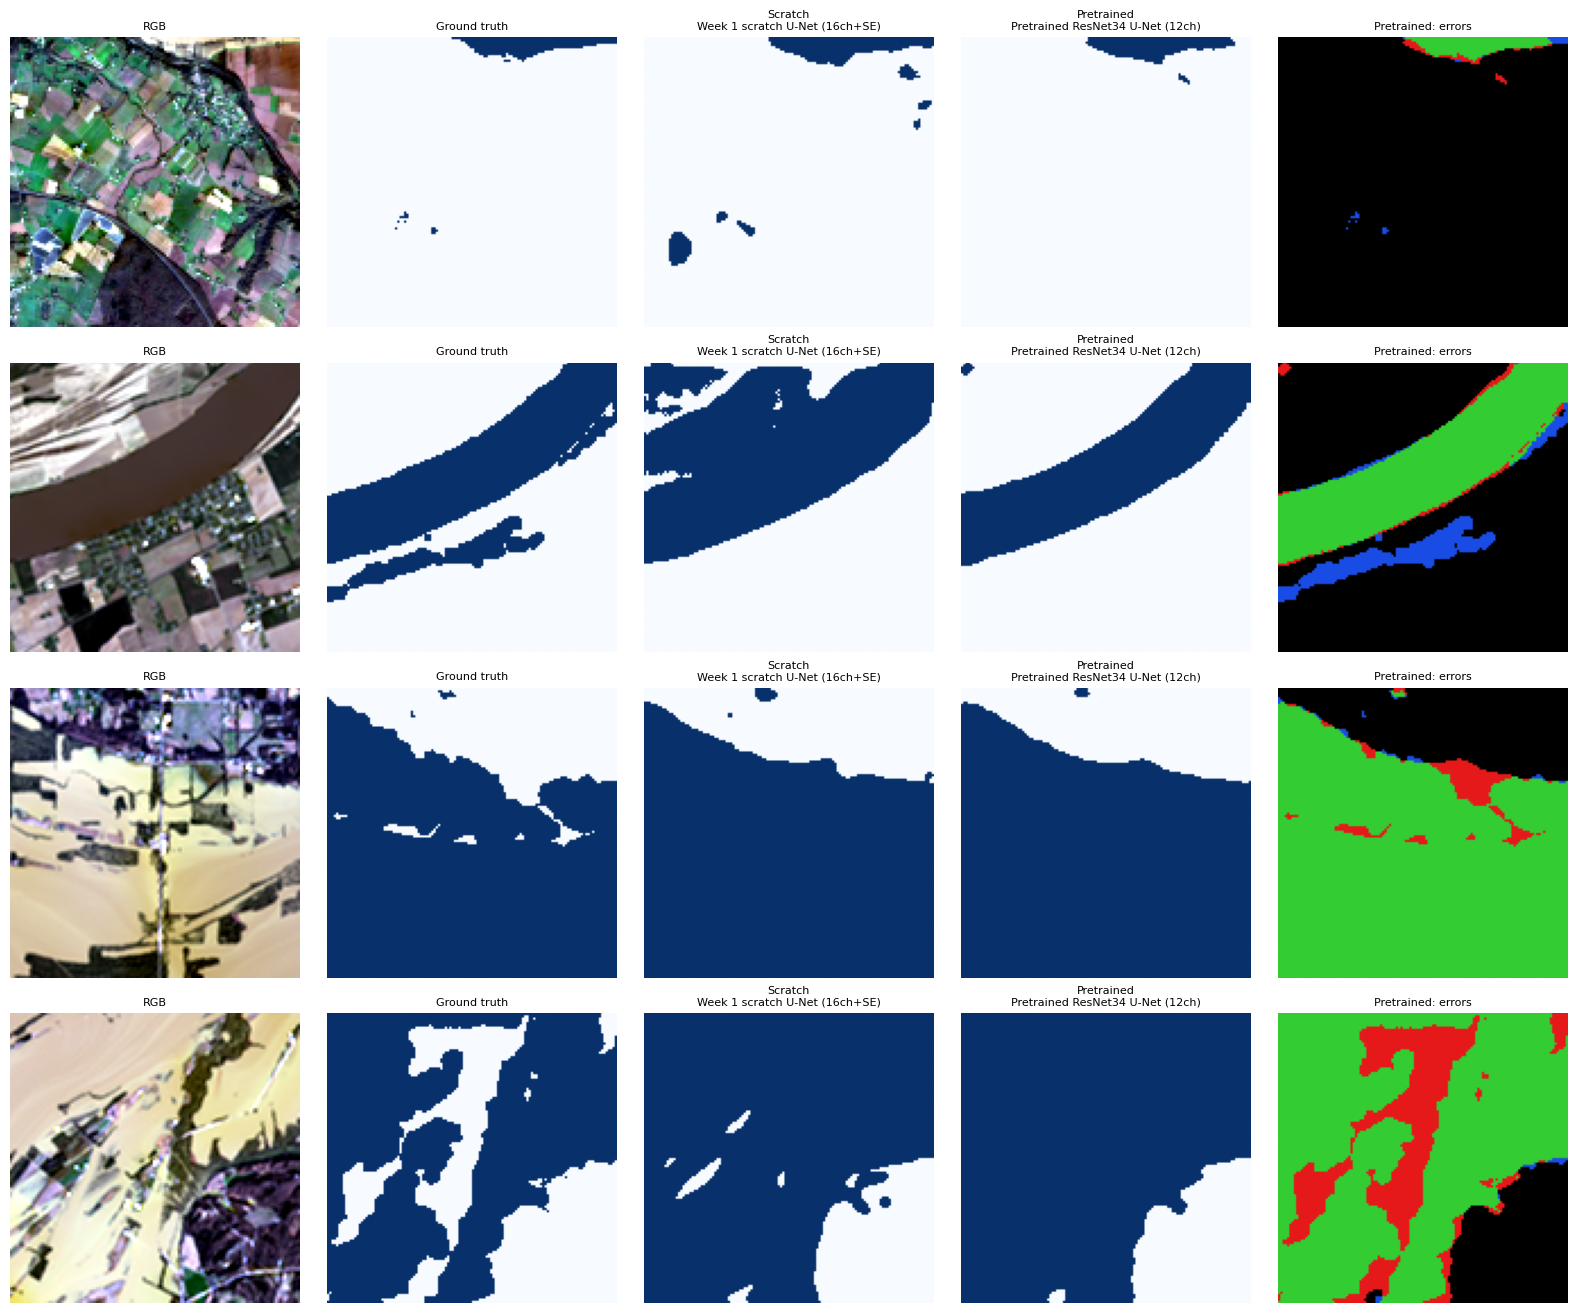

In [18]:
@torch.no_grad()
def predict_mask(entry, stem):
    model = entry['model'].to(device).eval()
    img, mask = load_model_input(stem, entry['channels'] == 16)
    if entry['standardized']:
        c = img.shape[0]
        img = (img - Z_MEAN[:c, None, None]) / Z_STD[:c, None, None]
    pred = (torch.sigmoid(model(torch.from_numpy(img).float().unsqueeze(0).to(device))) > 0.5).float().cpu().numpy()[0, 0]
    entry['model'].cpu()
    return pred, mask

if scratch and pre:
    rng = random.Random(0)
    show = rng.sample(test_stems, 4)
    fig, axes = plt.subplots(len(show), 5, figsize=(16, 3.3 * len(show)))
    for r, stem in enumerate(show):
        raw = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
        rgb = np.stack([stretch(raw[3]), stretch(raw[2]), stretch(raw[1])], axis=-1)
        p_s, mask = predict_mask(trained[best_s], stem)
        p_p, _    = predict_mask(trained[best_p], stem)
        err = np.zeros(mask.shape + (3,))
        err[(p_p == 1) & (mask == 1)] = (0.2, 0.8, 0.2)
        err[(p_p == 1) & (mask == 0)] = (0.9, 0.1, 0.1)
        err[(p_p == 0) & (mask == 1)] = (0.1, 0.3, 0.9)
        for ax, im, title, cmap in zip(axes[r], [rgb, mask, p_s, p_p, err],
                                       ['RGB', 'Ground truth', f'Scratch\n{best_s}', f'Pretrained\n{best_p}', 'Pretrained: errors'],
                                       [None, 'Blues', 'Blues', 'Blues', None]):
            ax.imshow(im, cmap=cmap); ax.set_title(title, fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'qualitative.png'), dpi=100, bbox_inches='tight'); plt.show()

## 12. Findings: which model is better, and why *(complete after your run)*

Fill this in from the table above - this is the "document findings" deliverable.

**Questions to answer in your README**
1. Which model has the best **test IoU / F1**? By how much does it beat the best scratch U-Net? Is the gain bigger than run-to-run noise (re-run with another `SEED` if unsure)?
2. Did it converge faster (compare the validation-IoU curves and the `Train (min)` column)?
3. Precision vs. recall: does the pretrained model trade one for the other? (Week 1 baseline: recall 0.87 > precision 0.74, i.e. it over-predicts water.)
4. Did the 16-channel input (engineered indices) help the pretrained model, as it should in theory?
5. Cost: parameters and `ms/img`. Is the better model still fast enough for real-time use?
6. (If you ran the extras) zero-init vs. mean-init vs. random-init: did keeping the pretrained RGB filters matter?

**Reasons a pretrained encoder usually helps here:** generic low-level filters (edges, textures) are already learned; deeper, residual encoders give a larger receptive field; the zero-init strategy starts from a sensible model instead of random noise; and fine-tuning with a small encoder learning rate acts as a regularizer on a small dataset.

**Reasons it might NOT help much:** most of our channels (NIR, SWIR, DEM, QA) have no ImageNet counterpart, so their weights must be learned from scratch anyway; ResNet's stem downsamples 4x immediately, which can blur thin water bodies on 128x128 tiles; a 21M-parameter encoder can overfit a small dataset; and two input bands (ESA WorldCover, water occurrence) are near-leakage - when a couple of channels carry most of the answer, every architecture scores similarly.

In [19]:
# Save everything that is worth keeping (weights, tables, stats) in one folder
SAVE_DIR = os.path.join(OUTPUT_DIR, 'week2_outputs')
os.makedirs(SAVE_DIR, exist_ok=True)
for name, entry in trained.items():
    fname = re.sub(r'[^A-Za-z0-9]+', '_', name).strip('_').lower() + '.pt'
    torch.save(entry['model'].state_dict(), os.path.join(SAVE_DIR, fname))
df.to_csv(os.path.join(SAVE_DIR, 'model_comparison.csv'), index=False)
json.dump(minmax, open(os.path.join(SAVE_DIR, 'channel_minmax.json'), 'w'), indent=2)
json.dump(z, open(os.path.join(SAVE_DIR, 'input_zscore_stats.json'), 'w'), indent=2)
print("Saved to", SAVE_DIR, ":", sorted(os.listdir(SAVE_DIR)))

Saved to /kaggle/working/week2_outputs : ['channel_minmax.json', 'input_zscore_stats.json', 'model_comparison.csv', 'pretrained_resnet34_u_net_12ch.pt', 'pretrained_resnet34_u_net_16ch.pt', 'week_1_scratch_u_net_12ch.pt', 'week_1_scratch_u_net_16ch_se.pt']
